In [1]:
#Importação das bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Carregar o dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalizar os dados (equivalente ao transforms.ToTensor())
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [4]:
# Preparar os batches (equivalente ao DataLoader)
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

In [5]:
# Definir a rede neural simples (equivalente ao MLP)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Flatten
    layers.Dense(10)  # Camada única (equivalente a nn.Linear(28*28, 10))
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Compilar o modelo (equivalente a criterion e optimizer)
model.compile(
    optimizer=optimizers.SGD(learning_rate=0.1),
    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [7]:
# Treinar a rede (apenas 3 épocas para simplicidade)
losses_history = []
for epoch in range(3):
    running_loss = 0.0
    for images, labels in train_dataset:
        with tf.GradientTape() as tape:
            logits = model(images, training=True)
            loss = losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
            mean_loss = tf.reduce_mean(loss)

        gradients = tape.gradient(mean_loss, model.trainable_variables)
        model.optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        running_loss += mean_loss

    epoch_loss = running_loss / len(train_dataset)
    losses_history.append(epoch_loss)
    print(f'Época {epoch+1}, Loss: {epoch_loss:.4f}')

Época 1, Loss: 0.4791
Época 2, Loss: 0.3373
Época 3, Loss: 0.3149


In [8]:
# Teste e avaliação
test_loss, test_acc = model.evaluate(test_dataset)
print(f'Acurácia: {100 * test_acc:.2f}%')

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9183 - loss: 0.2935
Acurácia: 91.83%


In [9]:
# Inferência em uma única imagem
def inferencia(model, image):
    image = tf.expand_dims(image, 0)  # Adicionar dimensão de batch
    logits = model(image, training=False)
    prediction = tf.argmax(logits, axis=1).numpy()[0]
    return prediction

In [10]:
# Testando a inferência com uma imagem do conjunto de teste
sample_image = x_test[0]


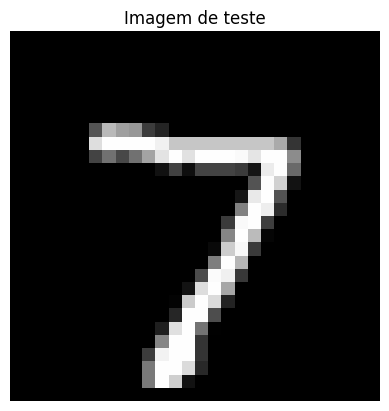

Predição da imagem: 7


In [11]:
# Mostrar a imagem antes da inferência
plt.imshow(sample_image, cmap='gray')
plt.title("Imagem de teste")
plt.axis("off")
plt.show()
predicao = inferencia(model, sample_image)
print(f'Predição da imagem: {predicao}')

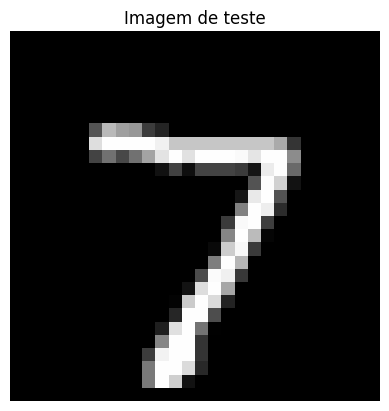

Predição da imagem: 7


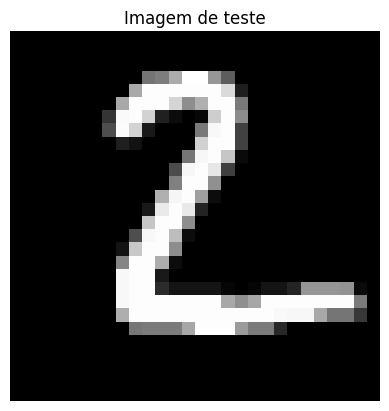

Predição da imagem: 2


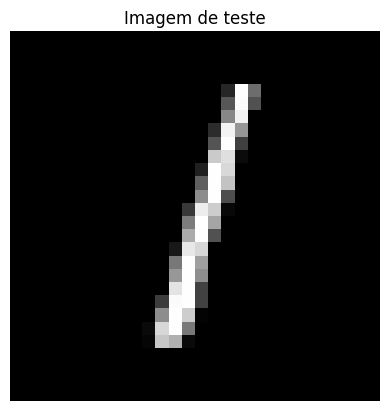

Predição da imagem: 1


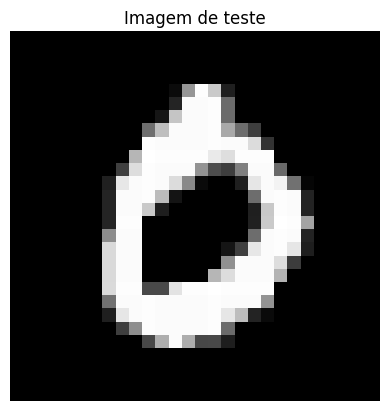

Predição da imagem: 0


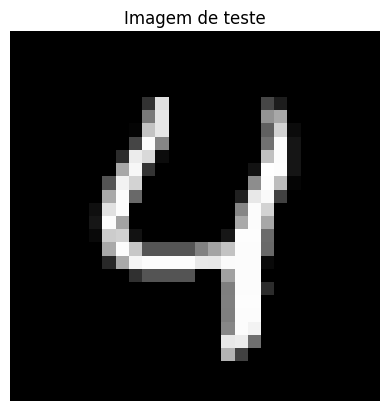

Predição da imagem: 4


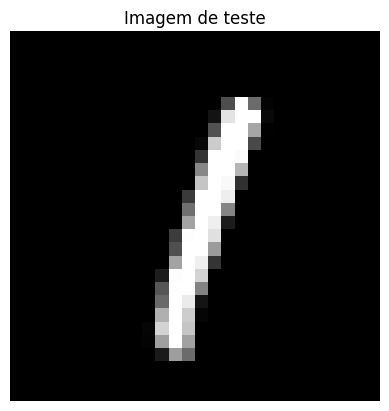

Predição da imagem: 1


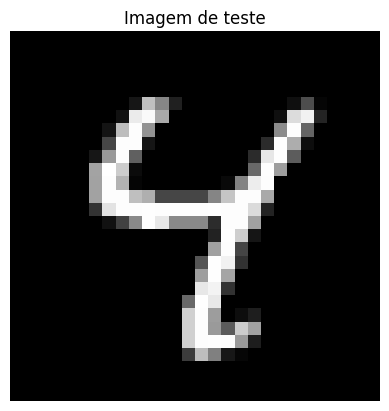

Predição da imagem: 4


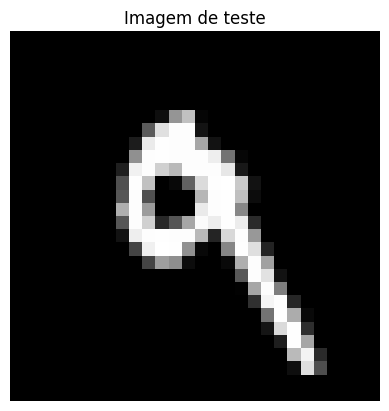

Predição da imagem: 9


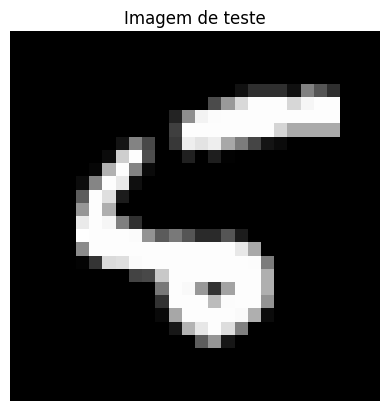

Predição da imagem: 6


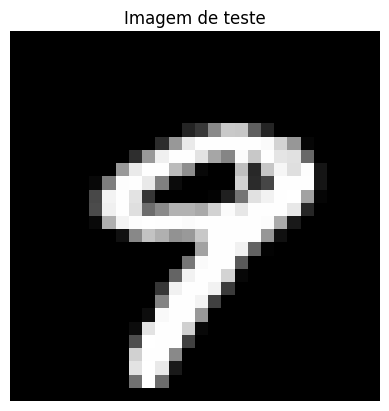

Predição da imagem: 9


In [12]:
# Inferência em várias imagens
for i in range(10):
    sample_image = x_test[i]
    # Mostrar a imagem antes da inferência
    plt.imshow(sample_image, cmap='gray')
    plt.title("Imagem de teste")
    plt.axis("off")
    plt.show()
    predicao = inferencia(model, sample_image)
    print(f'Predição da imagem: {predicao}')